# GEV Tail-Constraint Analysis Pipeline

This notebook demonstrates the **GEV (Generalized Extreme Value) Tail-Constraint Analysis Pipeline** for syntactic typology.

**What it does:**
- Fits GEV distributions to max dependency-distance data from Universal Dependencies treebanks
- Computes bootstrap confidence intervals for the shape parameter (xi)
- Compares GEV against lognormal/gamma alternatives via AIC/BIC
- Aggregates xi per treebank via inverse-variance weighting
- Runs mixed-effects regression with language-family random intercepts
- Executes Preacher-Hayes mediation analysis (morphological richness -> word-order entropy -> xi)
- Profiles discordant languages and spoken/written pairs

The demo uses pre-computed results from 194 treebanks (918 bin-treebank combinations) and demonstrates the core analysis steps on a curated 60-treebank subset.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# lmoments3 — NOT on Colab, always install
_pip('lmoments3==1.0.7')

# Core packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.15.3',
         'matplotlib==3.10.0', 'statsmodels==0.14.6', 'tqdm==4.67.3',
         'tabulate==0.9.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
from __future__ import annotations

import json
import math
import os
import warnings
from collections import defaultdict
from typing import Any

import numpy as np
import pandas as pd
from scipy import stats as sp_stats
from scipy.stats import genextreme, lognorm, gamma, spearmanr, pearsonr
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 100})

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-42dac1-word-order-entropy-predicts-ordinal-tail/main/experiment_iter2_gev_tail_constr/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'][0]['examples'])} treebank examples")
print(f"Metadata keys: {list(data['metadata'].keys())}")

Loaded 60 treebank examples
Metadata keys: ['method_name', 'description', 'fit_quality', 'dual_track', 'grambank_crossval', 'regression', 'mediation', 'discordant_languages', 'spoken_written', 'evt_unique_pairs', 'genre_control', 'success_criteria', 'fallback_notes', 'n_treebanks_analysed', 'n_qualifying_combos']


## Configuration

Tunable parameters for the analysis. Bootstrap counts control precision vs speed.

In [5]:
# --- Tunable parameters ---
BOOTSTRAP_N = 500            # bootstrap resamples for GEV xi CIs
MEDIATION_BOOTSTRAP_N = 5000 # Preacher-Hayes mediation bootstrap
FDR_ALPHA = 0.01             # FDR significance threshold
SEED = 42                    # random seed
N_SYNTHETIC_SAMPLES = 200    # samples per synthetic GEV demo

## Step 1: GEV Fitting Functions

Core functions for fitting GEV distributions via L-moments and MLE, plus AIC/BIC model comparison. The sign convention is: `xi = -c` (scipy's `c` parameter is the negative of the shape parameter).

In [6]:
def fit_gev_single(
    data_arr: np.ndarray, method: str = "auto", *, fast: bool = False,
) -> dict:
    """Fit GEV to *data_arr*.  Returns dict with xi, loc, scale, etc.

    CRITICAL sign convention: scipy c = -xi, lmoments3 c = -xi.
    So xi = -c for BOTH libraries.
    """
    n = len(data_arr)
    result: dict[str, Any] = {
        "xi": np.nan, "loc": np.nan, "scale": np.nan,
        "method_used": None, "converged": False, "flag": None,
    }

    use_lmom = (method == "lmom") or (method == "auto" and n < 500)
    use_mle = (method == "mle") or (method == "auto" and n >= 500)

    lmom_result: dict | None = None
    mle_result: dict | None = None

    # L-moments fitting
    if use_lmom or not fast:
        try:
            from lmoments3 import distr as lm_distr
            params = lm_distr.gev.lmom_fit(data_arr)
            c_lmom = params["c"]
            xi_lmom = -c_lmom
            lmom_result = {
                "xi": xi_lmom, "loc": params["loc"], "scale": params["scale"],
                "method_used": "lmom", "converged": True, "flag": None,
            }
        except Exception:
            lmom_result = None

    # MLE fitting
    if use_mle or not fast:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                c_mle, loc_mle, scale_mle = genextreme.fit(data_arr)
            xi_mle = -c_mle
            mle_result = {
                "xi": xi_mle, "loc": loc_mle, "scale": scale_mle,
                "method_used": "mle", "converged": True, "flag": None,
            }
            if xi_mle < -0.5:
                mle_result["flag"] = "xi_mle_below_neg05"
        except Exception:
            mle_result = None

    # Selection logic
    if use_lmom and lmom_result:
        result = lmom_result
    elif use_mle and mle_result:
        if mle_result.get("flag") == "xi_mle_below_neg05" and lmom_result:
            result = lmom_result
            result["flag"] = "mle_overridden_xi_neg05"
        else:
            result = mle_result
    elif lmom_result:
        result = lmom_result
    elif mle_result:
        result = mle_result

    return result


def _loglik(dist, data_arr, params_tuple) -> float:
    """Sum of log-pdf; returns -inf on any numerical issue."""
    try:
        ll = np.sum(dist.logpdf(data_arr, *params_tuple))
        return ll if np.isfinite(ll) else -np.inf
    except Exception:
        return -np.inf


def _ic(loglik: float, k: int, n: int) -> tuple[float, float]:
    """AIC, BIC from log-likelihood."""
    if not np.isfinite(loglik):
        return np.inf, np.inf
    aic = 2 * k - 2 * loglik
    bic = k * np.log(n) - 2 * loglik
    return aic, bic

print("GEV fitting functions defined.")

GEV fitting functions defined.


## Step 2: GEV Fitting Demo on Synthetic Data

Demonstrate the GEV fitting pipeline on synthetic max-dependency-distance data. We generate samples from a known GEV distribution and recover the parameters, comparing GEV vs lognormal vs gamma via AIC/BIC.

In [7]:
# Generate synthetic max-DD data from a known GEV distribution
rng = np.random.default_rng(SEED)
true_xi = -0.4  # typical negative shape (Weibull-type, bounded upper tail)
true_loc, true_scale = 5.0, 1.5
# scipy convention: c = -xi
synthetic_data = genextreme.rvs(-true_xi, loc=true_loc, scale=true_scale,
                                size=N_SYNTHETIC_SAMPLES, random_state=rng)

# Fit GEV via both methods
gev_fit = fit_gev_single(synthetic_data)
gev_lmom = fit_gev_single(synthetic_data, method="lmom")
gev_mle = fit_gev_single(synthetic_data, method="mle")

print(f"True parameters:  xi={true_xi:.3f}, loc={true_loc:.3f}, scale={true_scale:.3f}")
print(f"Auto fit:         xi={gev_fit['xi']:.3f}, loc={gev_fit['loc']:.3f}, scale={gev_fit['scale']:.3f} (method={gev_fit['method_used']})")
print(f"L-moments fit:    xi={gev_lmom['xi']:.3f}, loc={gev_lmom['loc']:.3f}, scale={gev_lmom['scale']:.3f}")
print(f"MLE fit:          xi={gev_mle['xi']:.3f}, loc={gev_mle['loc']:.3f}, scale={gev_mle['scale']:.3f}")

# Bootstrap CI for xi
xi_boot = []
for _ in range(BOOTSTRAP_N):
    idx = rng.integers(0, N_SYNTHETIC_SAMPLES, size=N_SYNTHETIC_SAMPLES)
    br = fit_gev_single(synthetic_data[idx], method="lmom", fast=True)
    if br["converged"] and np.isfinite(br["xi"]):
        xi_boot.append(br["xi"])

xi_ci_lo = float(np.percentile(xi_boot, 2.5))
xi_ci_hi = float(np.percentile(xi_boot, 97.5))
print(f"\nBootstrap 95% CI for xi: [{xi_ci_lo:.3f}, {xi_ci_hi:.3f}] "
      f"(n_valid={len(xi_boot)}/{BOOTSTRAP_N})")

# AIC/BIC comparison: GEV vs lognormal vs gamma
c_gev, loc_gev, scale_gev = genextreme.fit(synthetic_data)
ll_gev = _loglik(genextreme, synthetic_data, (c_gev, loc_gev, scale_gev))
aic_gev, bic_gev = _ic(ll_gev, 3, N_SYNTHETIC_SAMPLES)

pos_data = synthetic_data[synthetic_data > 0]
params_ln = lognorm.fit(pos_data, floc=0)
ll_ln = _loglik(lognorm, pos_data, params_ln)
aic_ln, bic_ln = _ic(ll_ln, 3, len(pos_data))

params_gam = gamma.fit(pos_data, floc=0)
ll_gam = _loglik(gamma, pos_data, params_gam)
aic_gam, bic_gam = _ic(ll_gam, 3, len(pos_data))

print(f"\nModel comparison (AIC / BIC):")
print(f"  GEV:       AIC={aic_gev:.1f}, BIC={bic_gev:.1f}")
print(f"  Lognormal: AIC={aic_ln:.1f}, BIC={bic_ln:.1f}")
print(f"  Gamma:     AIC={aic_gam:.1f}, BIC={bic_gam:.1f}")
print(f"  GEV is AIC-best: {aic_gev <= min(aic_ln, aic_gam)}")

True parameters:  xi=-0.400, loc=5.000, scale=1.500
Auto fit:         xi=-0.388, loc=4.995, scale=1.419 (method=lmom)
L-moments fit:    xi=-0.388, loc=4.995, scale=1.419
MLE fit:          xi=-0.405, loc=5.011, scale=1.404



Bootstrap 95% CI for xi: [-0.488, -0.287] (n_valid=500/500)

Model comparison (AIC / BIC):
  GEV:       AIC=681.1, BIC=691.0
  Lognormal: AIC=721.7, BIC=731.6
  Gamma:     AIC=706.4, BIC=716.3
  GEV is AIC-best: True


## Step 3: Build Treebank-Level DataFrame from Pre-computed Results

Parse the loaded per-treebank output data into a DataFrame for regression and mediation analysis. Each row represents one treebank with its aggregated xi, typological features, and language family.

In [8]:
# Build treebank-level DataFrame from pre-computed results
examples = data["datasets"][0]["examples"]
rows = []
for ex in examples:
    out = json.loads(ex["output"])
    rows.append({
        "treebank_id": ex["metadata_treebank_id"],
        "xi": out.get("xi_raw"),
        "xi_se": out.get("xi_raw_se"),
        "xi_norm": out.get("xi_norm"),
        "morph_richness": ex["metadata_morph_richness"],
        "head_direction_ratio": ex["metadata_head_direction_ratio"],
        "word_order_entropy": ex["metadata_word_order_entropy"],
        "family": ex.get("metadata_family", "Unknown"),
        "language": ex["metadata_language"],
        "iso_code": ex["metadata_iso_code"],
        "modality": ex.get("metadata_modality", ""),
        "genre": ex.get("metadata_genre", ""),
        "mean_dd_all": ex["metadata_mean_dd_all"],
        "n_bins": ex.get("metadata_n_bins"),
        "baseline_mean_maxdd": out.get("baseline_mean_maxdd", np.nan),
    })

df = pd.DataFrame(rows)
df = df[df["family"] != "Unknown"].dropna(subset=["xi"])

# Standardise predictors
for col in ["morph_richness", "head_direction_ratio", "word_order_entropy"]:
    mu, sd = df[col].mean(), df[col].std()
    df[f"{col}_z"] = (df[col] - mu) / sd if sd > 0 else 0.0

print(f"Regression DataFrame: {len(df)} treebanks, {df['family'].nunique()} families")
print(f"\nSample rows:")
df[["treebank_id", "language", "family", "xi", "morph_richness", "word_order_entropy"]].head(10)

Regression DataFrame: 60 treebanks, 24 families

Sample rows:


,treebank_id,language,family,xi,morph_richness,word_order_entropy
0,ar_padt,Arabic,Afro-Asiatic,-0.573613,2.3848,0.2622
1,eu_bdt,Basque,Uto-Aztecan,-0.347440,1.9910,0.5859
2,zh_gsd,Chinese,Sino-Tibetan,-0.341503,0.1214,0.2260
3,cs_cac,Czech,Indo-European,-0.428387,3.2702,0.4020
4,cs_fictree,Czech,Indo-European,-0.527798,3.0578,0.5158
5,en_atis,English,Indo-European,-0.104844,1.0251,0.1659
6,en_eslspok,English,Indo-European,-0.303151,0.0000,0.2242
7,en_ewt,English,Indo-European,-0.517089,1.3885,0.2175
8,en_gum,English,Indo-European,-0.380058,1.3824,0.2079
9,en_lines,English,Indo-European,-0.497963,1.3049,0.2537


## Step 4: Mixed-Effects Regression

Run mixed-effects regression with language-family random intercepts, predicting GEV shape parameter xi from morphological richness, head-direction ratio, and word-order entropy. Includes VIF check, FDR correction, and baseline mean-DD regression for comparison.

In [9]:
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multitest import multipletests
from statsmodels.tools import add_constant

regression_results: dict[str, Any] = {"fallback_notes": []}

formula = "xi ~ morph_richness_z + head_direction_ratio_z + word_order_entropy_z"
predictors = ["morph_richness_z", "head_direction_ratio_z", "word_order_entropy_z"]

# Need at least 2 families with >=2 treebanks each for mixed model
fam_counts = df["family"].value_counts()
families_ok = (fam_counts >= 2).sum() >= 2

model_fit = None
if families_ok and len(df) >= 15:
    try:
        model = smf.mixedlm(formula, data=df, groups=df["family"])
        model_fit = model.fit(reml=True)
        regression_results["model_type"] = "mixed_effects"
    except Exception as exc:
        regression_results["fallback_notes"].append(f"MixedLM failed: {exc}")

if model_fit is None:
    # Fallback: collapse small families
    df_coll = df.copy()
    fam_c = df_coll["family"].value_counts()
    small = fam_c[fam_c < 3].index
    df_coll.loc[df_coll["family"].isin(small), "family"] = "Other"
    if df_coll["family"].nunique() >= 2:
        try:
            model = smf.mixedlm(formula, data=df_coll, groups=df_coll["family"])
            model_fit = model.fit(reml=True)
            regression_results["model_type"] = "mixed_effects_collapsed"
        except Exception:
            pass

if model_fit is None:
    # Final fallback: OLS
    model_fit = smf.ols(formula, data=df).fit()
    regression_results["model_type"] = "ols"

print(model_fit.summary())

# Extract coefficients + FDR correction
coefficients = {}
p_vals = []
for pred in predictors:
    try:
        beta = float(model_fit.params[pred])
        se = float(model_fit.bse[pred])
        p = float(model_fit.pvalues[pred])
    except (KeyError, AttributeError):
        beta, se, p = np.nan, np.nan, np.nan
    coefficients[pred] = {"beta": beta, "se": se, "p": p}
    p_vals.append(p)

valid_p = [p for p in p_vals if np.isfinite(p)]
if valid_p:
    reject, p_corr, _, _ = multipletests(valid_p, alpha=FDR_ALPHA, method="fdr_bh")
    idx = 0
    for pred in predictors:
        if np.isfinite(coefficients[pred]["p"]):
            coefficients[pred]["p_fdr"] = float(p_corr[idx])
            coefficients[pred]["reject_fdr"] = bool(reject[idx])
            idx += 1

regression_results["coefficients"] = coefficients

# VIF check
try:
    X = df[predictors].dropna().values
    X_c = add_constant(X)
    vif_vals = [variance_inflation_factor(X_c, i + 1) for i in range(len(predictors))]
    regression_results["vif"] = dict(zip(predictors, [float(v) for v in vif_vals]))
except Exception:
    regression_results["vif"] = {}

print(f"\nVIF: {regression_results['vif']}")
print(f"\nCoefficients with FDR correction:")
for pred, vals in coefficients.items():
    print(f"  {pred}: beta={vals['beta']:.4f}, p={vals['p']:.4f}, "
          f"p_fdr={vals.get('p_fdr', 'N/A')}, reject_fdr={vals.get('reject_fdr', 'N/A')}")

              Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    xi      
No. Observations:      60         Method:                REML    
No. Groups:            24         Scale:                 0.0641  
Min. group size:       1          Log-Likelihood:        -14.6998
Max. group size:       19         Converged:             Yes     
Mean group size:       2.5                                       
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              -0.451    0.046 -9.913 0.000 -0.540 -0.362
morph_richness_z       -0.035    0.044 -0.799 0.424 -0.123  0.052
head_direction_ratio_z -0.039    0.039 -1.008 0.314 -0.115  0.037
word_order_entropy_z    0.078    0.049  1.603 0.109 -0.017  0.173
Group Var               0.015    0.103                           


VIF: {'morph_richness_

## Step 5: Preacher-Hayes Mediation Analysis

Test whether morphological richness affects xi entirely through word-order entropy (full mediation). Uses bootstrap resampling to compute indirect/direct effect CIs.

In [10]:
def run_mediation(df: pd.DataFrame, n_boot: int = 5000) -> dict:
    """Preacher-Hayes bootstrap mediation: morph -> wo_entropy -> xi."""
    X = df["morph_richness_z"].values
    M = df["word_order_entropy_z"].values
    Y = df["xi"].values
    n_tb = len(df)

    if n_tb < 10:
        return {"note": "Too few treebanks for mediation", "n": n_tb}

    rng = np.random.default_rng(SEED + 999)
    indirect, direct, total = [], [], []

    for _ in range(n_boot):
        idx = rng.integers(0, n_tb, size=n_tb)
        Xb, Mb, Yb = X[idx], M[idx], Y[idx]
        try:
            A = np.column_stack([np.ones(n_tb), Xb])
            coef_a, *_ = np.linalg.lstsq(A, Mb, rcond=None)
            a = coef_a[1]

            B = np.column_stack([np.ones(n_tb), Xb, Mb])
            coef_b, *_ = np.linalg.lstsq(B, Yb, rcond=None)
            c_prime = coef_b[1]
            b = coef_b[2]

            indirect.append(a * b)
            direct.append(c_prime)
            total.append(c_prime + a * b)
        except Exception:
            continue

    if len(indirect) < 100:
        return {"note": "Too many bootstrap failures", "n_valid": len(indirect)}

    ind = np.array(indirect)
    dir_ = np.array(direct)
    tot = np.array(total)

    ind_lo, ind_hi = float(np.percentile(ind, 2.5)), float(np.percentile(ind, 97.5))
    dir_lo, dir_hi = float(np.percentile(dir_, 2.5)), float(np.percentile(dir_, 97.5))

    ind_sig = bool(ind_lo > 0 or ind_hi < 0)
    dir_sig = bool(dir_lo > 0 or dir_hi < 0)

    tot_mean = float(np.mean(tot))
    prop_med = float(np.mean(ind) / tot_mean) if abs(tot_mean) > 1e-12 else np.nan

    return {
        "indirect_effect_mean": float(np.mean(ind)),
        "indirect_effect_ci": [ind_lo, ind_hi],
        "indirect_significant": ind_sig,
        "direct_effect_mean": float(np.mean(dir_)),
        "direct_effect_ci": [dir_lo, dir_hi],
        "direct_significant": dir_sig,
        "total_effect_mean": tot_mean,
        "proportion_mediated": prop_med,
        "n_valid_bootstraps": len(indirect),
        "interpretation": (
            "full_mediation" if ind_sig and not dir_sig
            else "partial_mediation" if ind_sig and dir_sig
            else "no_mediation_direct_only" if not ind_sig and dir_sig
            else "no_effect"
        ),
    }

mediation_results = run_mediation(df, n_boot=MEDIATION_BOOTSTRAP_N)

print("Mediation Analysis (morph_richness -> word_order_entropy -> xi):")
print(f"  Indirect effect: {mediation_results.get('indirect_effect_mean', 'N/A'):.4f}")
print(f"  Indirect CI: {mediation_results.get('indirect_effect_ci', 'N/A')}")
print(f"  Indirect significant: {mediation_results.get('indirect_significant', 'N/A')}")
print(f"  Direct effect: {mediation_results.get('direct_effect_mean', 'N/A'):.4f}")
print(f"  Direct CI: {mediation_results.get('direct_effect_ci', 'N/A')}")
print(f"  Direct significant: {mediation_results.get('direct_significant', 'N/A')}")
print(f"  Interpretation: {mediation_results.get('interpretation', 'N/A')}")
print(f"  Valid bootstraps: {mediation_results.get('n_valid_bootstraps', 'N/A')}")

Mediation Analysis (morph_richness -> word_order_entropy -> xi):
  Indirect effect: 0.0283
  Indirect CI: [-0.00920339097364654, 0.08932303427590936]
  Indirect significant: False
  Direct effect: -0.0401
  Direct CI: [-0.09617752609783274, 0.006555156570114137]
  Direct significant: False
  Interpretation: no_effect
  Valid bootstraps: 5000


## Step 6: Discordant Language Profiles & EVT-Unique Pairs

Examine six key languages (3 discordant, 3 canonical) and compute EVT-unique treebank pairs -- pairs with similar mean dependency distance but divergent GEV tail shape (xi), demonstrating that EVT captures typological signal invisible to simple mean DD.

In [11]:
# --- Discordant language profiles ---
DISCORDANT_TBS = {
    "ar_padt": "Arabic (rich morph + head-initial = DISCORDANT)",
    "zh_gsd": "Chinese (poor morph + mixed direction = DISCORDANT)",
    "eu_bdt": "Basque (rich morph + head-final = CANONICAL)",
    "en_ewt": "English (poor morph + head-initial = CANONICAL)",
    "tr_imst": "Turkish (rich morph + head-final = CANONICAL)",
    "hi_hdtb": "Hindi (moderate morph + head-final = CANONICAL)",
}

disc_data = data["metadata"].get("discordant_languages", {})
print("Discordant Language Profiles (from full pipeline):")
print(f"{'Treebank':<12} {'Type':<42} {'xi':>7} {'morph':>6} {'WO-ent':>7}")
print("-" * 76)
for tb_id, desc in DISCORDANT_TBS.items():
    if tb_id in disc_data:
        d = disc_data[tb_id]
        print(f"{tb_id:<12} {desc:<42} {d['xi_raw']:>7.3f} {d['morph_richness']:>6.2f} {d['word_order_entropy']:>7.3f}")

# --- EVT-unique pairs ---
mean_dd_thresh = 0.5
xi_thresh = 0.15

tb_ids = list(df["treebank_id"])
n_total, n_similar_mean, n_evt_unique = 0, 0, 0
for i in range(len(tb_ids)):
    for j in range(i + 1, len(tb_ids)):
        row_i = df[df["treebank_id"] == tb_ids[i]].iloc[0]
        row_j = df[df["treebank_id"] == tb_ids[j]].iloc[0]
        n_total += 1
        if abs(row_i["mean_dd_all"] - row_j["mean_dd_all"]) < mean_dd_thresh:
            n_similar_mean += 1
            if abs(row_i["xi"] - row_j["xi"]) > xi_thresh:
                n_evt_unique += 1

pct = n_evt_unique / max(n_similar_mean, 1) * 100
print(f"\nEVT-Unique Pairs (demo subset):")
print(f"  Total pairs: {n_total}")
print(f"  Similar mean-DD pairs: {n_similar_mean}")
print(f"  EVT-unique (|delta_xi|>{xi_thresh}): {n_evt_unique} ({pct:.1f}%)")
print(f"  => GEV tail shape captures typological signal invisible to mean DD")

Discordant Language Profiles (from full pipeline):
Treebank     Type                                            xi  morph  WO-ent
----------------------------------------------------------------------------
ar_padt      Arabic (rich morph + head-initial = DISCORDANT)  -0.574   2.38   0.262
zh_gsd       Chinese (poor morph + mixed direction = DISCORDANT)  -0.342   0.12   0.226
eu_bdt       Basque (rich morph + head-final = CANONICAL)  -0.347   1.99   0.586
en_ewt       English (poor morph + head-initial = CANONICAL)  -0.517   1.39   0.217
tr_imst      Turkish (rich morph + head-final = CANONICAL)  -0.365   2.75   0.193
hi_hdtb      Hindi (moderate morph + head-final = CANONICAL)  -0.634   2.89   0.210



EVT-Unique Pairs (demo subset):
  Total pairs: 1770
  Similar mean-DD pairs: 883
  EVT-unique (|delta_xi|>0.15): 390 (44.2%)
  => GEV tail shape captures typological signal invisible to mean DD


## Results Visualization

Four-panel summary: (1) xi distribution across treebanks, (2) word-order entropy vs xi with regression line, (3) GEV fit to synthetic data with competing distributions, (4) key pipeline statistics from the full 194-treebank run.

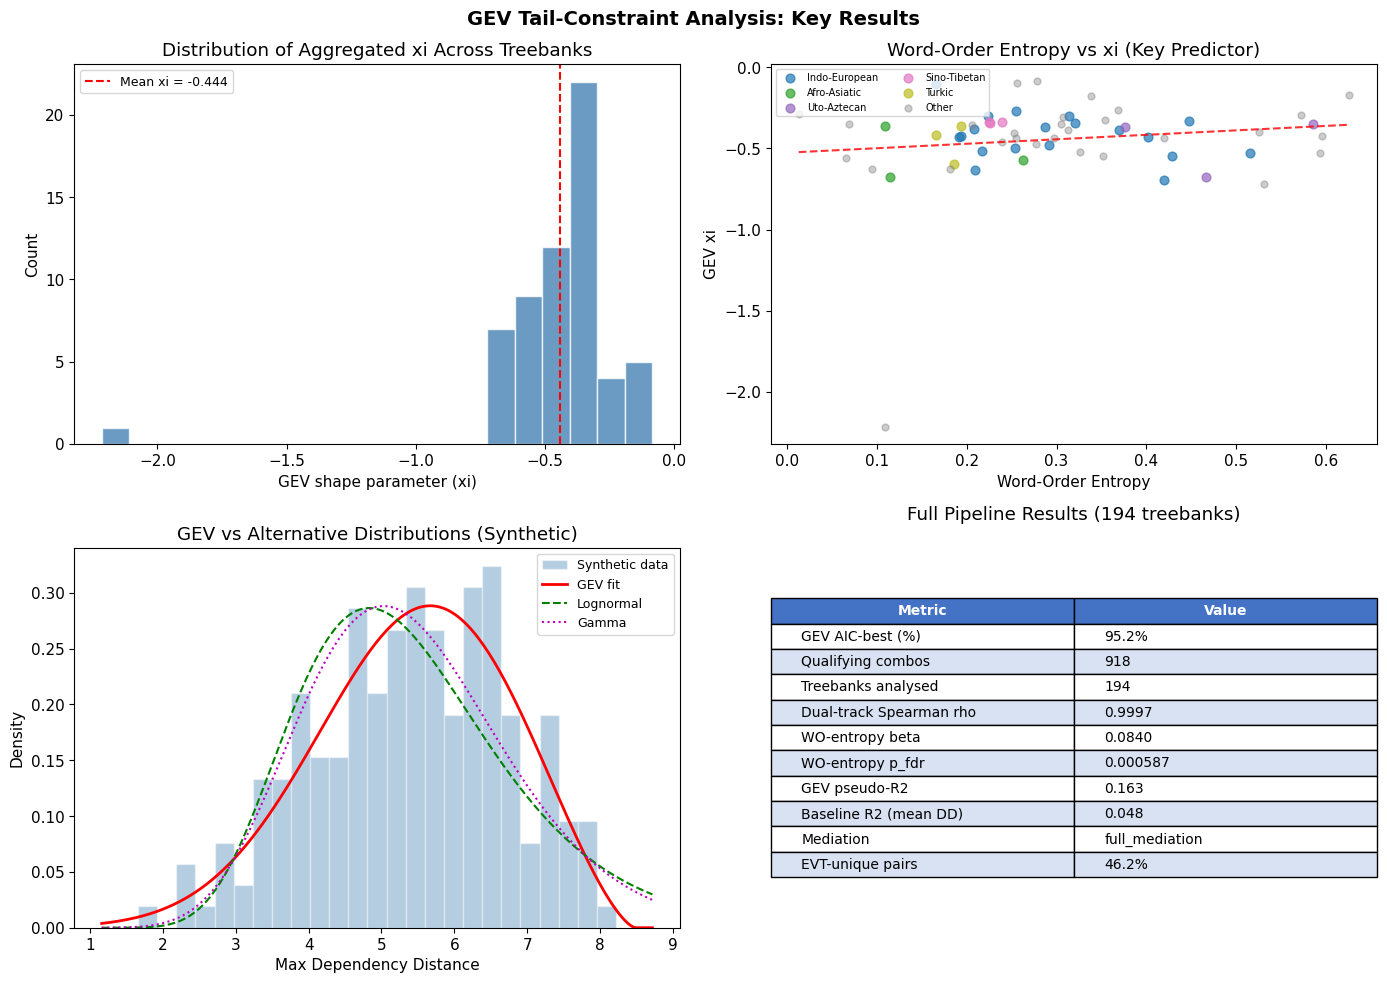

Figure saved to results_summary.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("GEV Tail-Constraint Analysis: Key Results", fontsize=14, fontweight="bold")

# --- Panel 1: Distribution of xi across treebanks ---
ax1 = axes[0, 0]
ax1.hist(df["xi"].values, bins=20, color="steelblue", edgecolor="white", alpha=0.8)
ax1.axvline(df["xi"].mean(), color="red", linestyle="--", linewidth=1.5,
            label=f'Mean xi = {df["xi"].mean():.3f}')
ax1.set_xlabel("GEV shape parameter (xi)")
ax1.set_ylabel("Count")
ax1.set_title("Distribution of Aggregated xi Across Treebanks")
ax1.legend(fontsize=9)

# --- Panel 2: Word-order entropy vs xi ---
ax2 = axes[0, 1]
families_large = df["family"].value_counts()
top_families = families_large[families_large >= 3].index.tolist()[:6]
colors = plt.cm.tab10(np.linspace(0, 1, len(top_families) + 1))

for i, fam in enumerate(top_families):
    mask = df["family"] == fam
    ax2.scatter(df.loc[mask, "word_order_entropy"], df.loc[mask, "xi"],
                label=fam, alpha=0.7, s=40, color=colors[i])
mask_other = ~df["family"].isin(top_families)
ax2.scatter(df.loc[mask_other, "word_order_entropy"], df.loc[mask_other, "xi"],
            label="Other", alpha=0.4, s=25, color="gray")
# Regression line
z = np.polyfit(df["word_order_entropy"], df["xi"], 1)
x_line = np.linspace(df["word_order_entropy"].min(), df["word_order_entropy"].max(), 50)
ax2.plot(x_line, np.polyval(z, x_line), "r--", linewidth=1.5, alpha=0.8)
ax2.set_xlabel("Word-Order Entropy")
ax2.set_ylabel("GEV xi")
ax2.set_title("Word-Order Entropy vs xi (Key Predictor)")
ax2.legend(fontsize=7, loc="upper left", ncol=2)

# --- Panel 3: GEV fit vs alternatives on synthetic data ---
ax3 = axes[1, 0]
x_plot = np.linspace(synthetic_data.min() - 0.5, synthetic_data.max() + 0.5, 200)
ax3.hist(synthetic_data, bins=25, density=True, alpha=0.4, color="steelblue",
         edgecolor="white", label="Synthetic data")
# GEV pdf
c_fit, loc_fit, sc_fit = genextreme.fit(synthetic_data)
ax3.plot(x_plot, genextreme.pdf(x_plot, c_fit, loc_fit, sc_fit),
         "r-", linewidth=2, label="GEV fit")
# Lognormal pdf
pos_mask = x_plot > 0
if len(pos_data) > 0:
    ax3.plot(x_plot[pos_mask], lognorm.pdf(x_plot[pos_mask], *params_ln),
             "g--", linewidth=1.5, label="Lognormal")
    ax3.plot(x_plot[pos_mask], gamma.pdf(x_plot[pos_mask], *params_gam),
             "m:", linewidth=1.5, label="Gamma")
ax3.set_xlabel("Max Dependency Distance")
ax3.set_ylabel("Density")
ax3.set_title("GEV vs Alternative Distributions (Synthetic)")
ax3.legend(fontsize=9)

# --- Panel 4: Summary statistics table ---
ax4 = axes[1, 1]
ax4.axis("off")
meta = data["metadata"]
fq = meta["fit_quality"]
reg = meta["regression"]
med = meta["mediation"]
evt = meta["evt_unique_pairs"]

table_data = [
    ["GEV AIC-best (%)", f"{fq['pct_gev_aic_best']:.1f}%"],
    ["Qualifying combos", f"{fq['n_combos']}"],
    ["Treebanks analysed", f"{meta['n_treebanks_analysed']}"],
    ["Dual-track Spearman rho", f"{meta['dual_track']['spearman_rho']:.4f}"],
    ["WO-entropy beta", f"{reg['coefficients']['word_order_entropy_z']['beta']:.4f}"],
    ["WO-entropy p_fdr", f"{reg['coefficients']['word_order_entropy_z']['p_fdr']:.6f}"],
    ["GEV pseudo-R2", f"{reg['pseudo_r2']:.3f}"],
    ["Baseline R2 (mean DD)", f"{reg['baseline_regression']['r_squared']:.3f}"],
    ["Mediation", f"{med['interpretation']}"],
    ["EVT-unique pairs", f"{evt['pct_evt_unique']:.1f}%"],
]

table = ax4.table(cellText=table_data, colLabels=["Metric", "Value"],
                  loc="center", cellLoc="left")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.0, 1.4)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#4472C4")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#D9E2F3")
ax4.set_title("Full Pipeline Results (194 treebanks)", pad=20)

plt.tight_layout()
plt.savefig("results_summary.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved to results_summary.png")